# EasyVisa  Assignment by **Prateek**

## Importing Usefull Libraries for Data Masagging, Visualization, Model Building

In [125]:

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np
import pgeocode

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split

# Libraries to build decision tree classifier
from sklearn.tree import DecisionTreeClassifier

from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    make_scorer,
)
import folium

#Encoding
from sklearn.preprocessing import LabelEncoder

# Library to suppress warnings or deprecation notes
import warnings
warnings.filterwarnings("ignore")

# Objective
- Goal: Build a Machine Learning classification model that can predict whether a visa application should be Certified or Denied.

## What the model should help with

- Speed up the visa screening process

- Shortlist applicants with high chances of approval

- Identify the key factors (drivers) that influence visa decisions

- Provide data-driven recommendations for future applicants

## Reading the data

In [126]:
df=pd.read_csv("EasyVisa.csv")

In [3]:
df_copy=df.copy()

## Sneek Peek into the data

In [4]:
df.head(5)

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


## Statistical Insights into the variable

In [9]:
df.shape

(25480, 12)

In [94]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
case_id,25480,25480,EZYV01,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
continent,25480,6,Asia,16861,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_of_employee,25480,4,Bachelor's,10234,NaN,NaN,NaN,NaN,NaN,NaN,NaN
has_job_experience,25480,2,Y,14802,NaN,NaN,NaN,NaN,NaN,NaN,NaN
requires_job_training,25480,2,N,22525,NaN,NaN,NaN,NaN,NaN,NaN,NaN
no_of_employees,25480.0,NaN,NaN,NaN,5667.04321,22877.928848,-26.0,1022.0,2109.0,3504.0,602069.0
yr_of_estab,25480.0,NaN,NaN,NaN,1979.409929,42.366929,1800.0,1976.0,1997.0,2005.0,2016.0
region_of_employment,25480,5,Northeast,7195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
prevailing_wage,25480.0,NaN,NaN,NaN,74455.814592,52815.942327,2.1367,34015.48,70308.21,107735.5125,319210.27
unit_of_wage,25480,4,Year,22962,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Observation
-  There are 25.48k rows and 12 columns.
-  3 integer and 9 categorical variables.
-  Most of the visa applications are from Asia and the common features include Bachelor's, has work experience, are looking for full time in northeastern part of USA.
-  Average year if establishment of the hiring company is 1976 and they are hiring for 90% FTE offers.
  

In [6]:
df.dtypes

case_id                   object
continent                 object
education_of_employee     object
has_job_experience        object
requires_job_training     object
no_of_employees            int64
yr_of_estab                int64
region_of_employment      object
prevailing_wage          float64
unit_of_wage              object
full_time_position        object
case_status               object
dtype: object

## Checking for Duplicates

In [7]:
df.duplicated().sum()

np.int64(0)

## Missing Value Detection & Treatement

In [8]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

### Observation
- There is no missing value and hence treatement is not required.

# Exploratory Data Analysis(EDA)

In [10]:
df.case_id.nunique()

25480

# Feature Engineering
- Creating buckets for easy visualization as volume is high and it is difficult to view any trend.

### Creating bucket for no_of_employees and checing for data quality

In [127]:
bins = [-100,0, 50, 200, 500, 1000, 5000, 10000, 50000, 100000, 500000, 2000000]

labels = ["<0",
    "0-50",
    "50-200",
    "200-500",
    "500-1K",
    "1K-5K",
    "5K-10K",
    "10K-50K",
    "50K-100K",
    "100K-500K",
    "500K+"
]

df['emp_bucket'] = pd.cut(df['no_of_employees'], bins=bins, labels=labels)


In [128]:
bucket_dist = df['emp_bucket'].value_counts(normalize=True).sort_index()*100
bucket_dist.round(2)


emp_bucket
<0            0.13
0-50          0.85
50-200        3.81
200-500       7.39
500-1K       12.32
1K-5K        65.16
5K-10K        4.71
10K-50K       3.38
50K-100K      1.19
100K-500K     1.04
500K+         0.02
Name: proportion, dtype: float64

In [129]:
# checking for experience <0
df[df["no_of_employees"] < 0]["no_of_employees"].unique()

array([-25, -11, -17, -26, -14])

In [130]:
# Correcting the experience values
df["no_of_employees"].replace(-25, 25, inplace=True)
df["no_of_employees"].replace(-11, 11, inplace=True)
df["no_of_employees"].replace(-17, 17, inplace=True)
df["no_of_employees"].replace(-26, 26, inplace=True)
df["no_of_employees"].replace(-14, 14, inplace=True)

## Creating Year Buckets for easy visualization

In [131]:
df["yr_of_estab_bin"] = pd.cut(
    df["yr_of_estab"],
    bins=[1800, 1850, 1900, 1950, 2000, 2500],
    labels=["1800-1850", "1850-1900","1900-1950","1950-2000", "2000+"]
)

## Age of the Company

In [166]:
df['company_age'] = 2024 - df['yr_of_estab']

# Univariate Analysis

## Observation on Continent

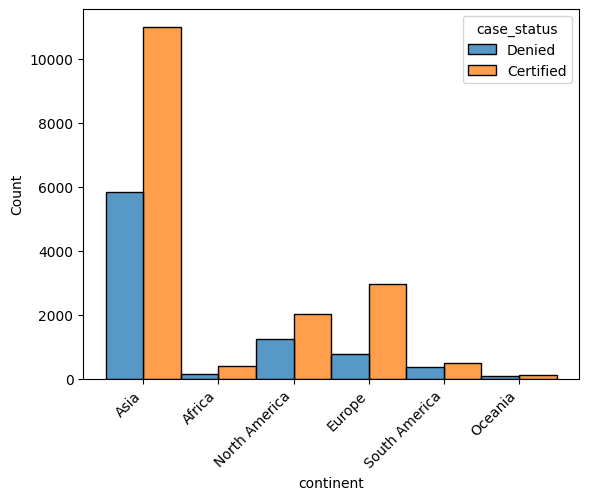

In [11]:
plt.tight_layout()
sns.histplot(data=df,x="continent",hue="case_status",multiple="dodge")
plt.xticks(rotation=45, ha='right')
plt.show()

## Observations
- ~25% Denied and ~40% Certified Applications are from Asia alone.
- North America, Europe being 2nd and 3rd to Aisa respectively.

## Observation on has_job_experience

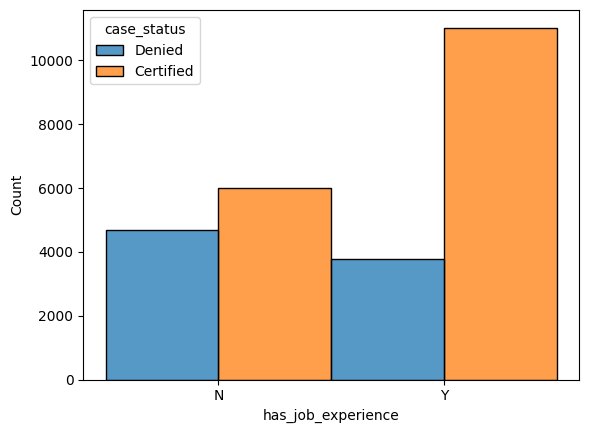

In [12]:
sns.histplot(data=df,x="has_job_experience",hue="case_status",multiple="dodge")
plt.show()

## Observations
- More than 60% of the Visa applicatoin have work experience and among that 70% got their Visa certified.

## Observation on requires_job_training

In [13]:
df["requires_job_training"].value_counts()

requires_job_training
N    22525
Y     2955
Name: count, dtype: int64

## Observations
- 88% of the Visa applicants don't require any formal training.

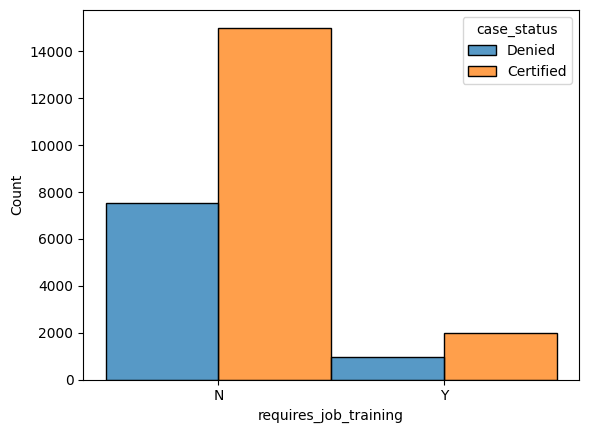

In [14]:
sns.histplot(data=df,x="requires_job_training",hue="case_status",multiple="dodge")
plt.show()

## Observation on full_time_position

In [15]:
df["full_time_position"].value_counts()

full_time_position
Y    22773
N     2707
Name: count, dtype: int64

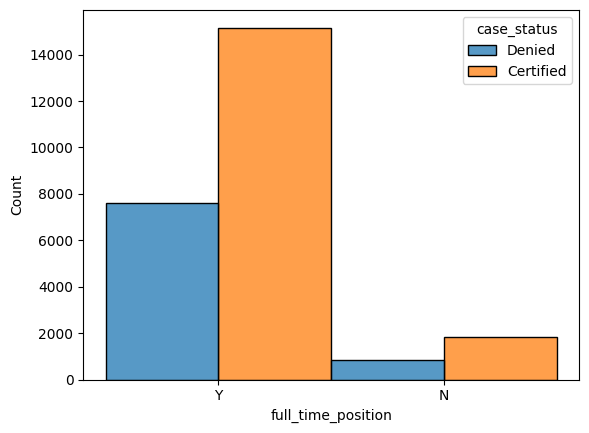

In [16]:
sns.histplot(data=df,x="full_time_position",hue="case_status",multiple="dodge")
plt.show()

## Observations
- Above 3 graph tells a strong story that applicants having job, requiring no job training and appying for a full time role are more probable to get Visa certified.

## Observation on no_of_employees

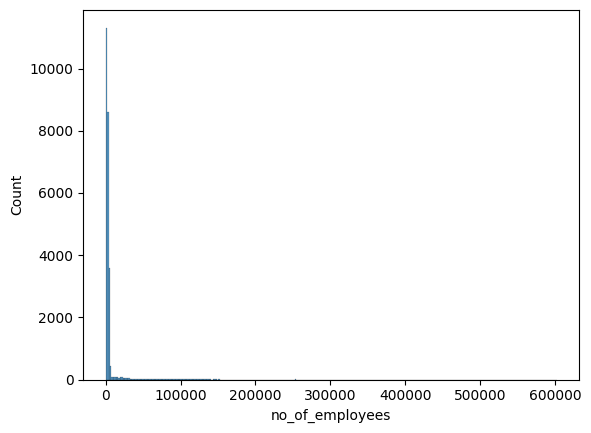

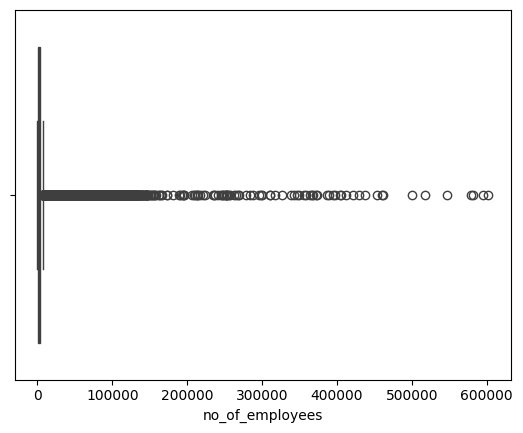

In [17]:
sns.histplot(data=df,x="no_of_employees")
plt.show()
sns.boxplot(data=df,x="no_of_employees")
plt.show()

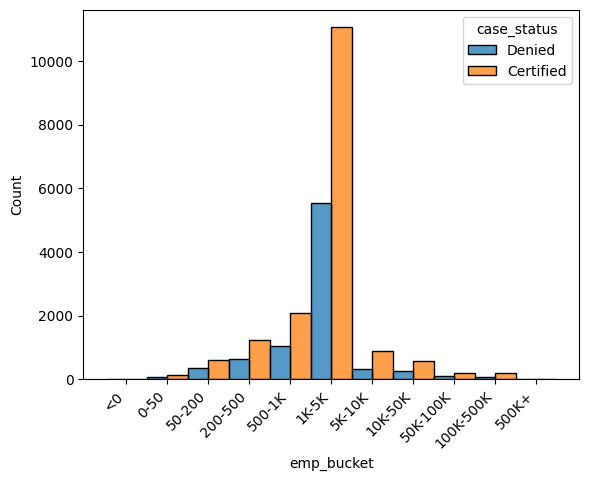

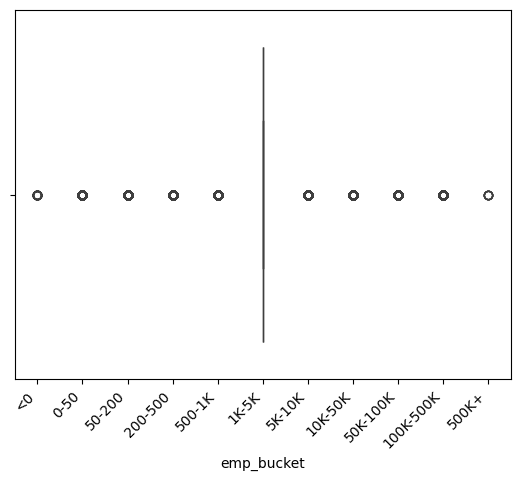

In [147]:
sns.histplot(data=df,x="emp_bucket",hue="case_status",multiple="dodge")
plt.xticks(rotation=45, ha='right')
plt.show()
sns.boxplot(data=df,x="emp_bucket")
plt.xticks(rotation=45, ha='right')
plt.show()

## Observation
- No. of employee is highly right skewed with many outliers on both sides.
- For Negative employees, could be data entry error, we can make them positive.

<Axes: xlabel='company_age', ylabel='Count'>

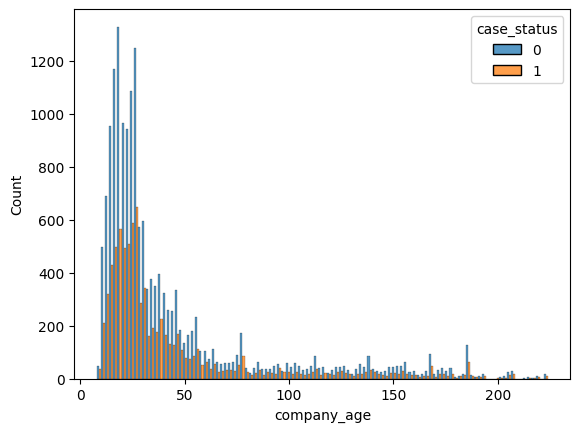

In [164]:
sns.histplot(data=df,x="company_age",hue="case_status",multiple="dodge")

## Observation on Company_age
- Almost ~50% of the companies are new and less than 50 yrs of age.
- Some are more than 200 yrs but very few.

<Axes: xlabel='yr_of_estab', ylabel='Count'>

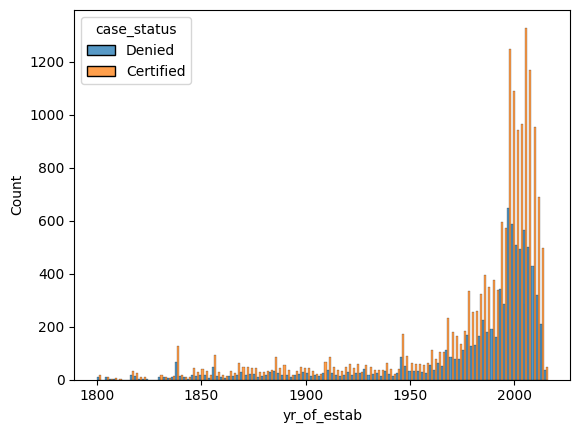

In [18]:
plt.tight_layout()
sns.histplot(data=df,x="yr_of_estab",hue="case_status",multiple="dodge")

## Observations
- Newly established companies have more number of certified visa's as compared to older one's though they also have more number of visa applications which means ratio Certified/Denied be same throughout.

## Observation on Region_of_employment

<Axes: xlabel='region_of_employment', ylabel='Count'>

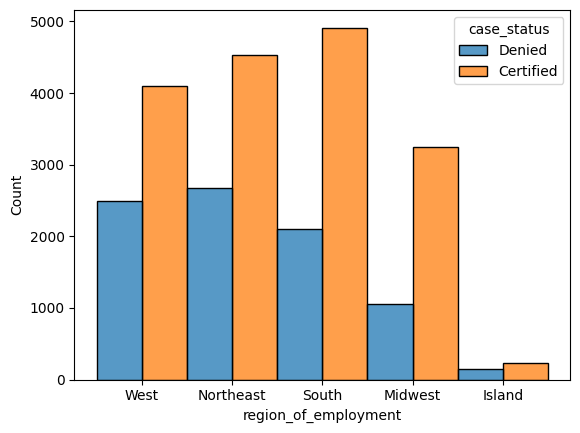

In [19]:
plt.tight_layout()
sns.histplot(data=df,x="region_of_employment",hue="case_status",multiple="dodge")

## Observations
- No strong corelation when it comes to region of application vs visa results.

## Observation on Unit_of_wage

<Axes: xlabel='unit_of_wage', ylabel='Count'>

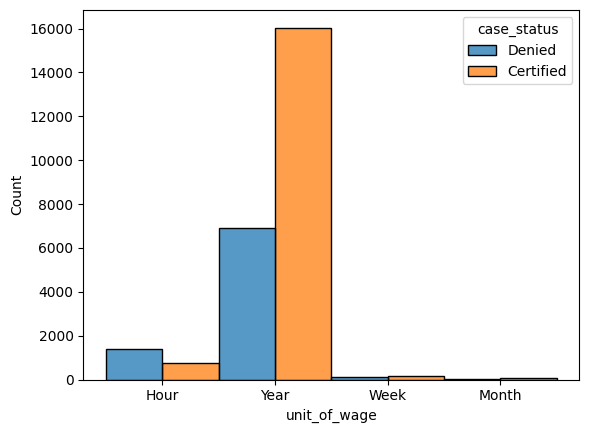

In [20]:
plt.tight_layout()
sns.histplot(data=df,x="unit_of_wage",hue="case_status",multiple="dodge")

## Observations
- Applicants on Yearly Unit wages are more likely to get certified.

## Observation Education_of_employee

<Axes: xlabel='education_of_employee', ylabel='Count'>

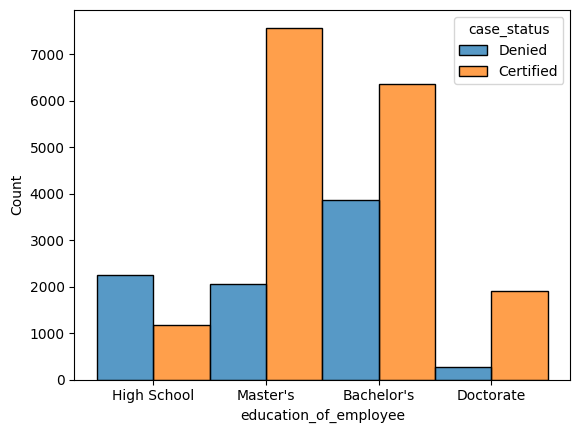

In [22]:
plt.tight_layout()
sns.histplot(data=df,x="education_of_employee",hue="case_status",multiple="dodge")

## Observations
- Bachelor's, Master's and Doctorate applicants have higher probability of visa certification. Also,Amongst them doctor's ratio of visa approval/denial is far greater than others.

## Observation on Unit_of_wage

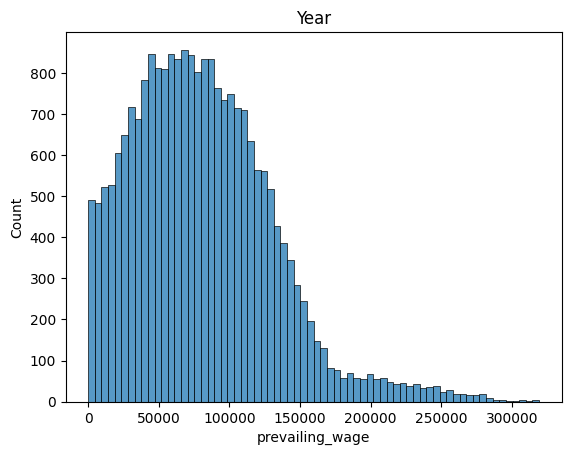

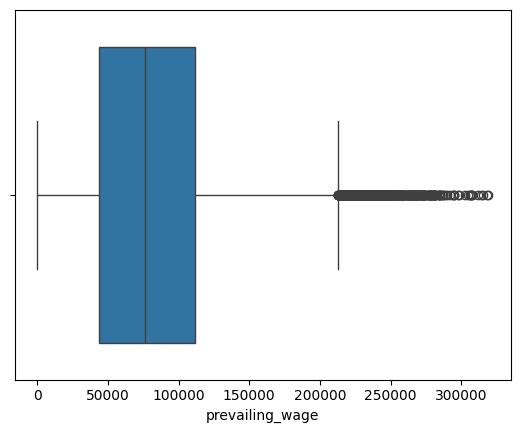

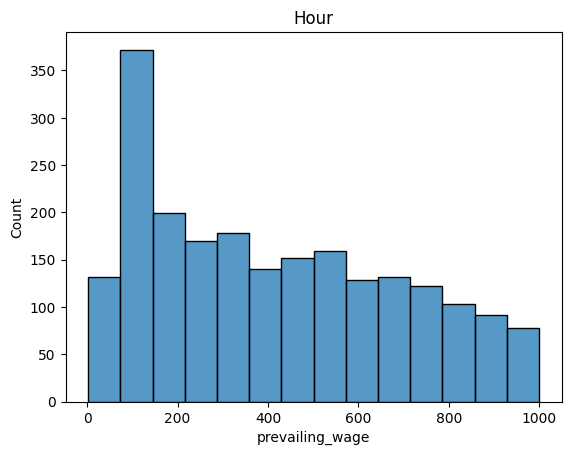

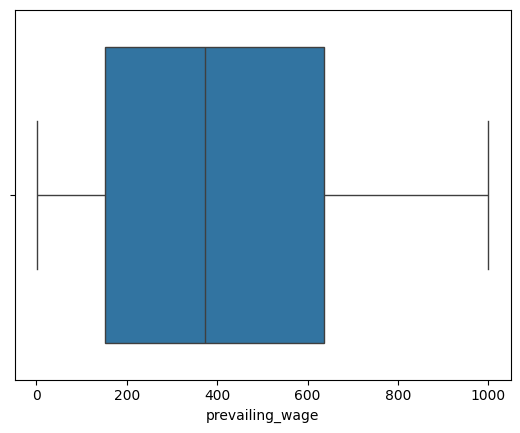

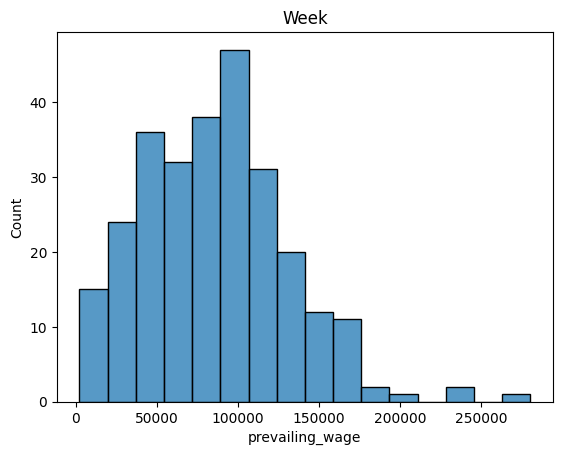

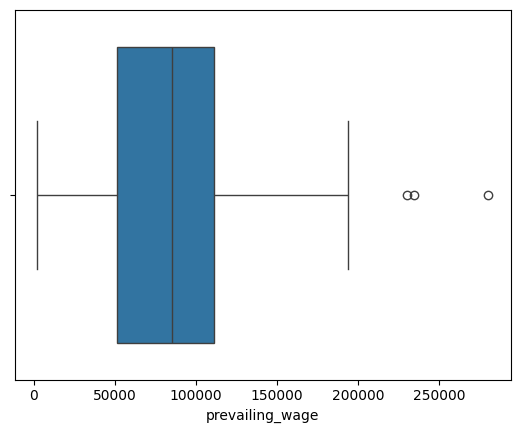

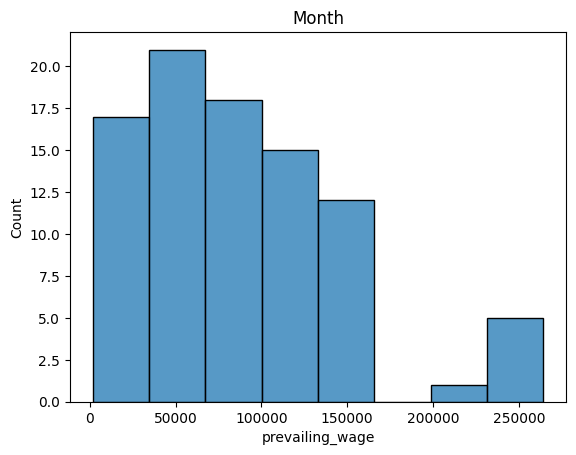

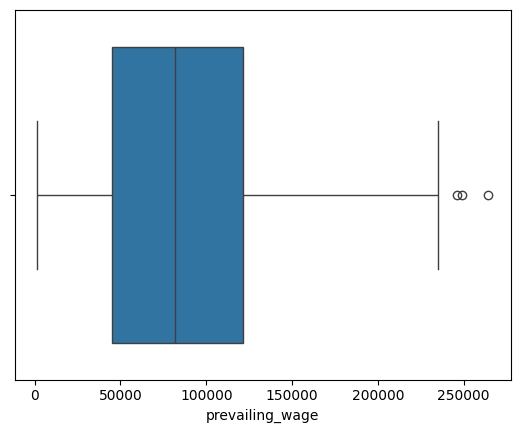

In [23]:
plt.tight_layout()
plt.title("Year")
sns.histplot(data=df[df["unit_of_wage"]=="Year"],x="prevailing_wage",multiple="dodge")
plt.show()
sns.boxplot(data=df[df["unit_of_wage"]=="Year"],x="prevailing_wage")
plt.show()
plt.title("Hour")
sns.histplot(data=df[df["unit_of_wage"]=="Hour"],x="prevailing_wage",multiple="dodge")
plt.show()
sns.boxplot(data=df[df["unit_of_wage"]=="Hour"],x="prevailing_wage")
plt.show()
plt.title("Week")
sns.histplot(data=df[df["unit_of_wage"]=="Week"],x="prevailing_wage",multiple="dodge")
plt.show()
sns.boxplot(data=df[df["unit_of_wage"]=="Week"],x="prevailing_wage")
plt.show()
plt.title("Month")
sns.histplot(data=df[df["unit_of_wage"]=="Month"],x="prevailing_wage",multiple="dodge")
plt.show()
sns.boxplot(data=df[df["unit_of_wage"]=="Month"],x="prevailing_wage")
plt.show()

## Observations
- Yearly wages has a normal distribution with a mean annual salary of 75k USD.
- Hourly wages have a similar distribution over a range of 200-1000 USD.
- Weekly wages have nomral distribution from 0-1.5M USD with outliers after that.
- Monthly wages also show a similar distribution.

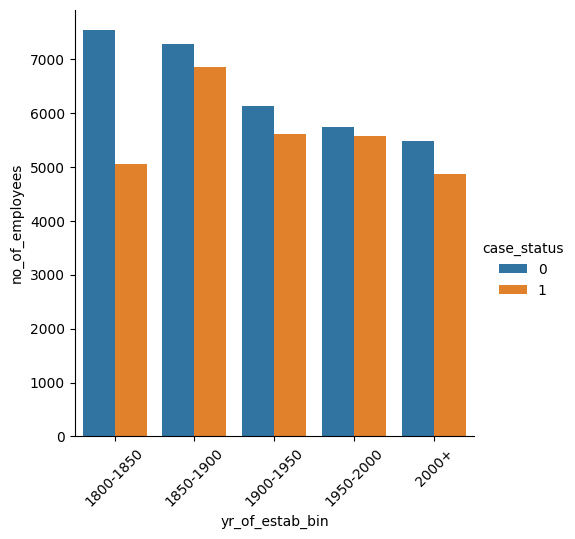

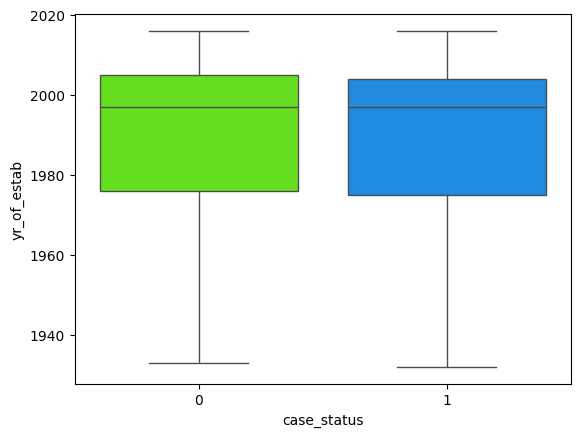

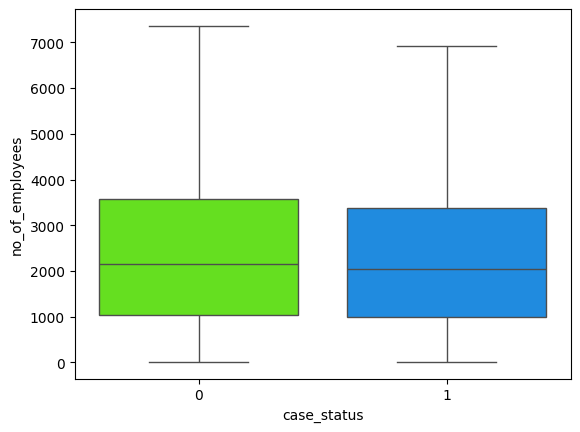

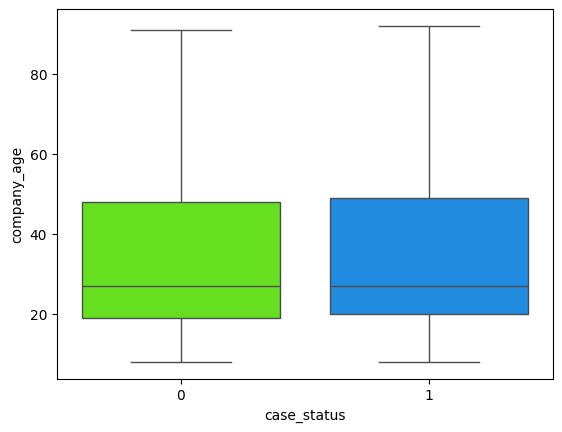

In [168]:
sns.catplot(x="yr_of_estab_bin",y="no_of_employees",data=df,kind="bar",hue="case_status",ci=None)
plt.xticks(rotation=45)
plt.show()
sns.boxplot(y="yr_of_estab",x="case_status",data=df, showfliers=False, palette="gist_rainbow")
plt.show()
sns.boxplot(y="no_of_employees",x="case_status",data=df, showfliers=False, palette="gist_rainbow")
plt.show()
sns.boxplot(y="company_age",x="case_status",data=df, showfliers=False, palette="gist_rainbow")
plt.show()


# Bivariate Analysis

## Prevailing_wage vs Unit_of_wage

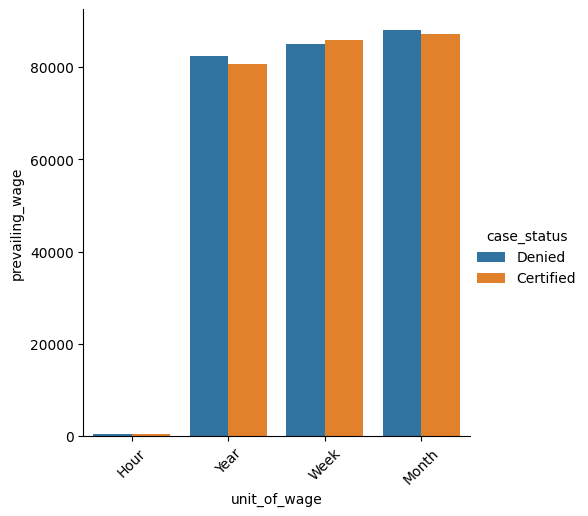

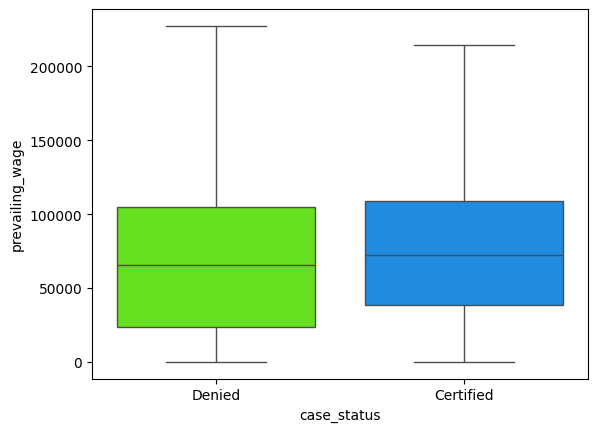

In [133]:
sns.catplot(y="prevailing_wage",x="unit_of_wage",data=df,kind="bar",hue="case_status",ci=None)
plt.xticks(rotation=45)
plt.show()
sns.boxplot(y="prevailing_wage",x="case_status",data=df, showfliers=False, palette="gist_rainbow")
plt.show()

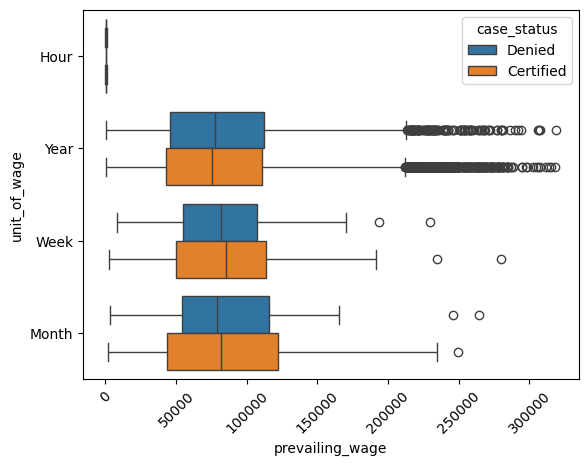

In [137]:
sns.boxplot(x="prevailing_wage",y="unit_of_wage",data=df,hue="case_status")
plt.xticks(rotation=45)
plt.show()

### Observations
- Outliers are not being treated as salaries are very subjective and changes wrt industry, position, technology.

## Prevailing_wage vs Region_of_employment

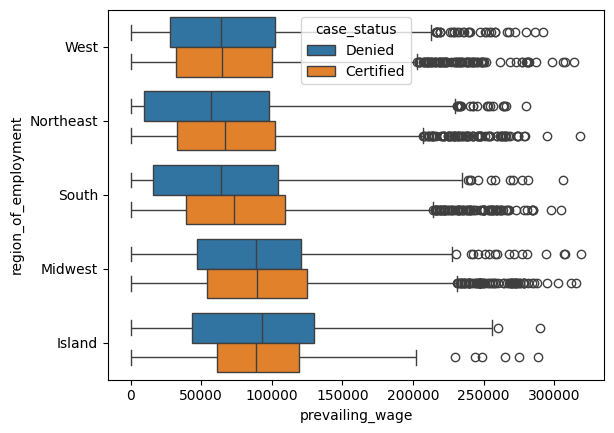

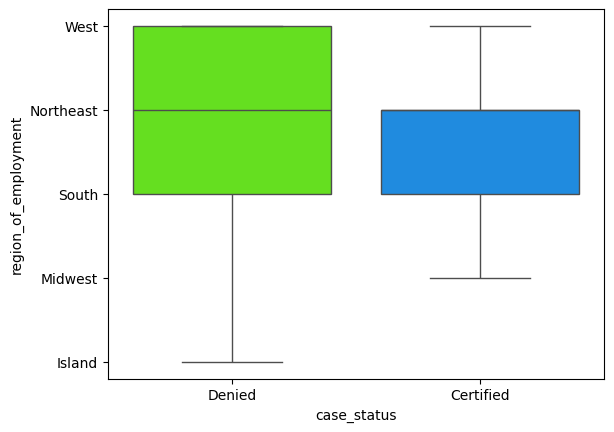

In [138]:
sns.boxplot(data=df,x="prevailing_wage",y="region_of_employment",hue="case_status")
plt.show()
sns.boxplot(y="region_of_employment",x="case_status",data=df, showfliers=False, palette="gist_rainbow")
plt.show()

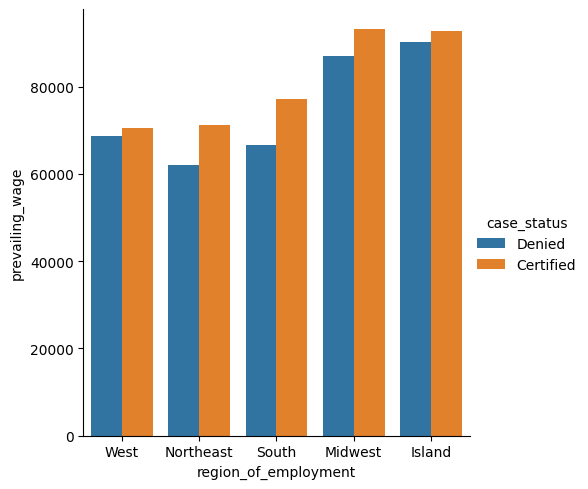

In [29]:
sns.catplot(data=df,y="prevailing_wage",x="region_of_employment",kind="bar",hue="case_status",ci=None)
plt.show()

## Education_of_employee vs Case_status

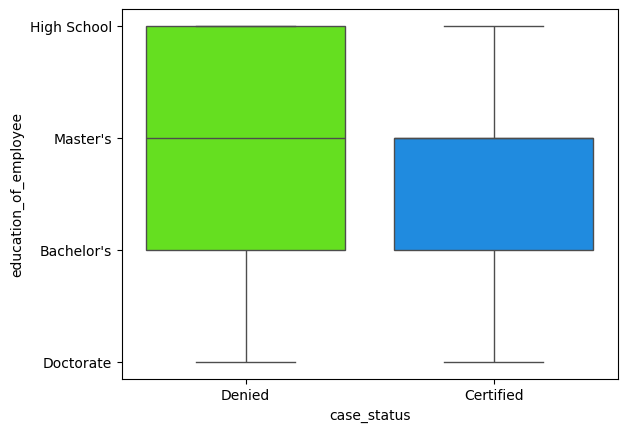

In [140]:
sns.boxplot(y="education_of_employee",x="case_status",data=df, showfliers=False, palette="gist_rainbow")
plt.show()

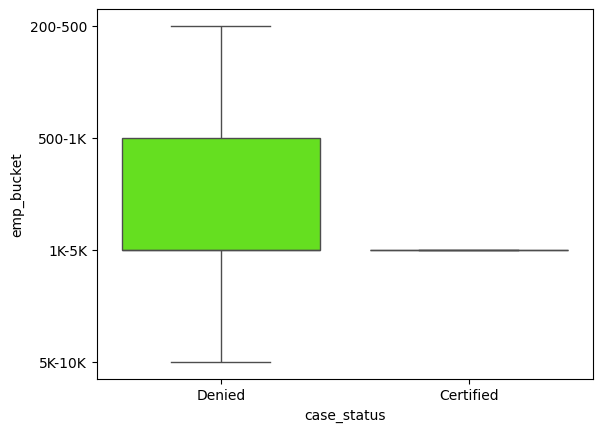

In [143]:
sns.boxplot(y="emp_bucket",x="case_status",data=df, showfliers=False, palette="gist_rainbow")
plt.show()

## Correlation Check

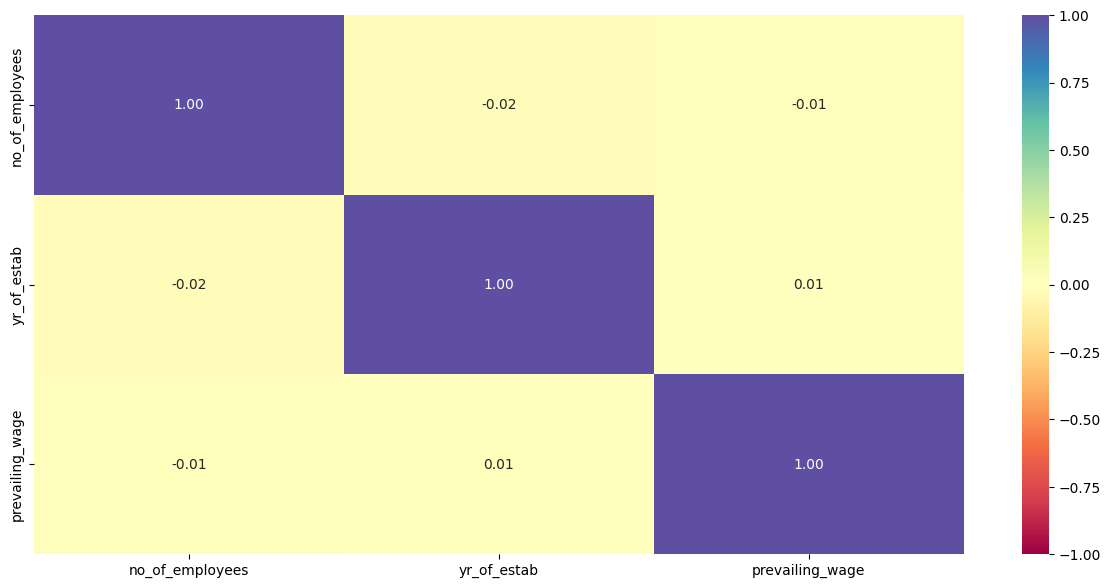

In [156]:
# Correlation plot
plt.figure(figsize=(15, 7))
sns.heatmap(df_copy.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

## Observation
- There is no positive/negative relationship between any variable which is quite strange.

## Data Preparation for Modeling
We have 7 categorical independent variables but 2 of them are binary.

### Label Encoding Varibables
- For tree models, Label Encoding is usually BETTER than One-Hot.

In [148]:
le = LabelEncoder()
df["case_status"] = le.fit_transform(df["case_status"])
df["continent"] = le.fit_transform(df["continent"])
df["education_of_employee"] = le.fit_transform(df["education_of_employee"])
df["has_job_experience"] = le.fit_transform(df["has_job_experience"])
df["requires_job_training"] = le.fit_transform(df["requires_job_training"])
df["region_of_employment"] = le.fit_transform(df["region_of_employment"])
df["full_time_position"] = le.fit_transform(df["full_time_position"])
df["unit_of_wage"] = le.fit_transform(df["unit_of_wage"])

In [158]:
x=df.drop(["case_id","yr_of_estab_bin","case_status","emp_bucket","yr_of_estab_bin"],axis=1)
y=df["case_status"]

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y )# Using stratify for equal target value distribution.

In [162]:
x.head()

,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position
0,1,2,0,0,14513,2007,4,592.2029,0,1
1,1,3,1,0,2412,2002,2,83425.6500,3,1
2,1,0,0,1,44444,2008,4,122996.8600,3,1
3,1,0,0,0,98,1897,4,83434.0300,3,1
4,0,3,1,0,1082,2005,3,149907.3900,3,1


In [35]:
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Percentage of classes in training set:
case_status
0    0.667919
1    0.332081
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
0    0.667844
1    0.332156
Name: proportion, dtype: float64


## Model Evaluation Criterion 

### The model predicts the visa application outcome:

1 → Certified (Approved)

0 → Denied

However, the model can make incorrect predictions in two ways:

### 1) Predicting a visa will be Certified, but in reality it is Denied

 This results in:

- Extra review workload for authorities

- Time and resource consumption

### 2) Predicting a visa will be Denied, but in reality it would be Certified

 This results in:

- Loss of skilled talent for employers

- Hiring delays and productivity loss

- Negative economic impact

### Which case is more important?

 The **second case** is more critical:

- Predicting that a visa will be denied when it would actually be approved.

 This is equivalent to losing a good candidate who could have contributed to the company and the economy.

### Business Goal

#### The primary objective of the model is to reduce False Negatives.

In this context:

**False Negative: Model predicts Denied, but the visa should be Certified.**

 **Minimizing False Negatives ensures that eligible candidates are not wrongly filtered out.**

### Model Evaluation Strategy

To reduce False Negatives, the bank/organization would want to maximize Recall for the Certified class.

Higher Recall → Fewer False Negatives → Fewer good candidates rejected.

### Creating functions for Evaluation, Confusion and Feature Importance

In [36]:
def evaluation_metric(model,pred,target):
    
    #acc = accuracy_score(target, model.predict(pred))  # to compute Accuracy
    recall = recall_score(target, model.predict(pred))  # to compute Recall
    precision = precision_score(target, model.predict(pred))  # to compute Precision
    #f1 = f1_score(target, model.predict(pred))  # to compute F1-score
    
    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
    {"Recall": recall, "Precision": precision},index=[0],)
    return df_perf

In [38]:
def confusion_matrix_sklearn(model, pred, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(pred)
    cm = confusion_matrix(y_pred,target)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## Feature Importance for Decision Tree and Random Forest

In [37]:
def importance(model, pred, target):
    importances = model.feature_importances_
    indices = np.argsort(importances)
    
    plt.title("Feature Importances")
    plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
    column_names = list(x.columns)
    feature_names = column_names
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel("Relative Importance")
    plt.show()

## Feature Importance for Bagging and Boosting Models

In [221]:
def ensemble_feature_importance(model, X):
    """
    Works for:
    Bagging, RandomForest, ExtraTrees, AdaBoost (tree base), GradientBoosting
    """

    # Case 1: Models that already provide feature_importances_
    if hasattr(model, "feature_importances_"):
        importance = model.feature_importances_

    # Case 2: Bagging / AdaBoost -> average importance of base estimators
    elif hasattr(model, "estimators_"):
        importances = []
        
        for est in model.estimators_:
            # AdaBoost stores estimators in array shape (n_estimators, 1)
            if isinstance(est, np.ndarray):
                est = est[0]
            
            if hasattr(est, "feature_importances_"):
                importances.append(est.feature_importances_)
        
        importance = np.mean(importances, axis=0)

    else:
        raise ValueError("Model does not support feature importance")

    # Create dataframe
    feat_imp = pd.DataFrame({
        "Feature": x.columns,
        "Importance": importance
    }).sort_values(by="Importance", ascending=False)

    # Plot
    plt.figure(figsize=(8,5))
    plt.barh(feat_imp["Feature"], feat_imp["Importance"])
    plt.gca().invert_yaxis()
    plt.title("Feature Importance - Ensemble Model")
    plt.xlabel("Importance")
    plt.show()


# Basic Models

## 1. Decision Tree(Basic Model + Original Data)


Training Performance:

   Recall  Precision
0     1.0        1.0

Test Performance:

     Recall  Precision
0  0.491138   0.480539


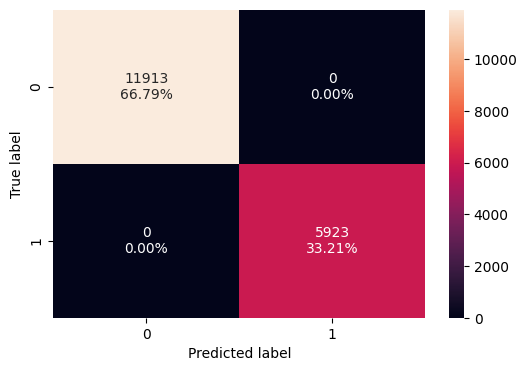

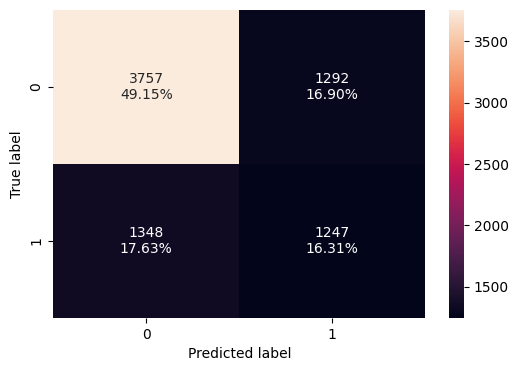

In [170]:
dt=DecisionTreeClassifier(criterion="gini",random_state=42)
dt.fit(x_train,y_train)

print("\n" "Training Performance:" "\n")
print(evaluation_metric(dt,x_train,y_train))
confusion_matrix_sklearn(dt,x_train,y_train)

print("\n" "Test Performance:" "\n")
print(evaluation_metric(dt,x_test,y_test))
confusion_matrix_sklearn(dt,x_test,y_test)

- 0 errors on the training set, each sample has been classified correctly.
- Model has performed very well on training set.
- As we know a decision tree will continue to grow and classify each data point correctly if no restrictions are applied as the trees will learn all the patterns in the training set.

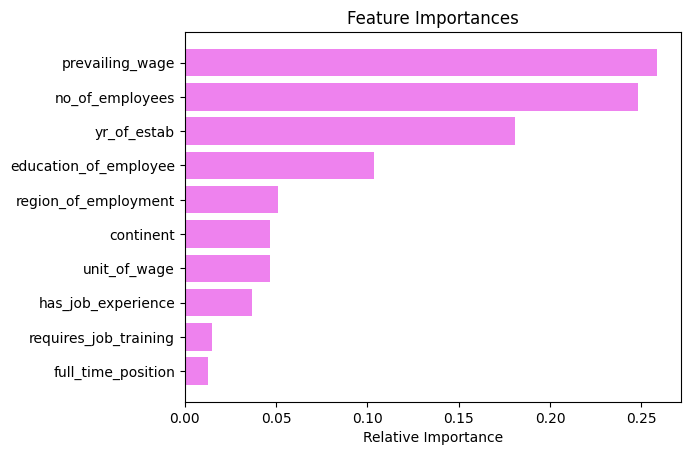

In [172]:
importance(dt, x_train, y_train)

- Prevailing_wage is the most important feature followed by no_of_employees, yr_of_estab and education_of_employee.

## 2. Random Forest(Basic Model + Original Data)


Training Performance:

   Recall  Precision
0     1.0        1.0

Test Performance:

     Recall  Precision
0  0.472627   0.625652


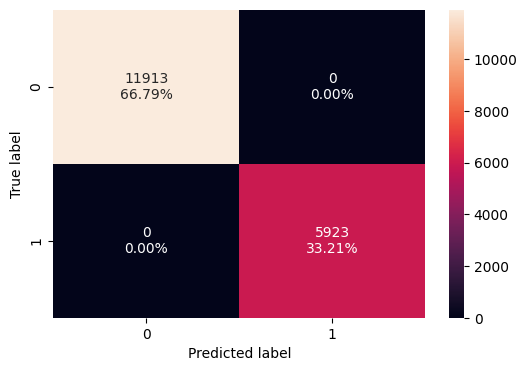

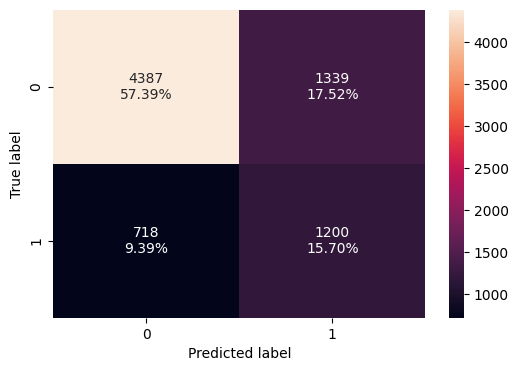

In [200]:
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)
print("\n" "Training Performance:" "\n")
print(evaluation_metric(rf,x_train,y_train))
confusion_matrix_sklearn(rf,x_train,y_train)

print("\n" "Test Performance:" "\n")
print(evaluation_metric(rf,x_test,y_test))
confusion_matrix_sklearn(rf,x_test,y_test)

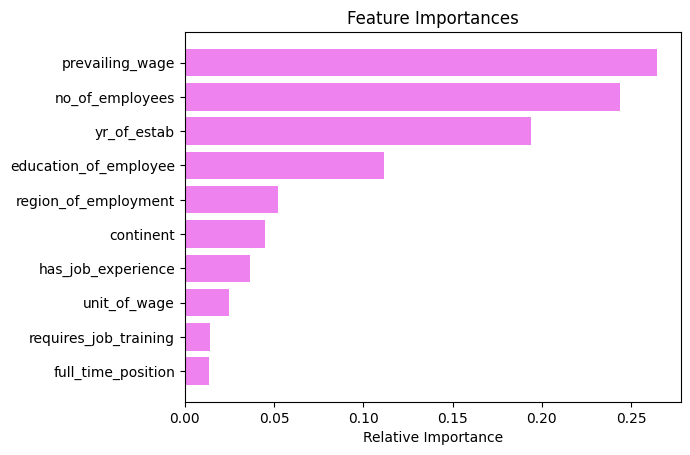

In [173]:
importance(rf, x_train, y_train)

- Random Forests has performed exactly same on training set as decision with same important features.
- Test performance is slighly different than decision tree

## 3. Bagging LR Model(Base Model + Original Data)


Training Performance:

     Recall  Precision
0  0.532332   0.426196

Test Performance:

     Recall  Precision
0  0.531312   0.425821


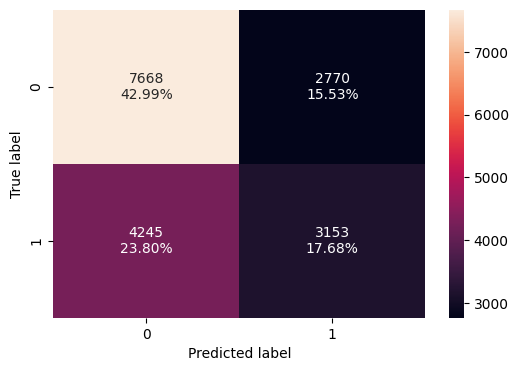

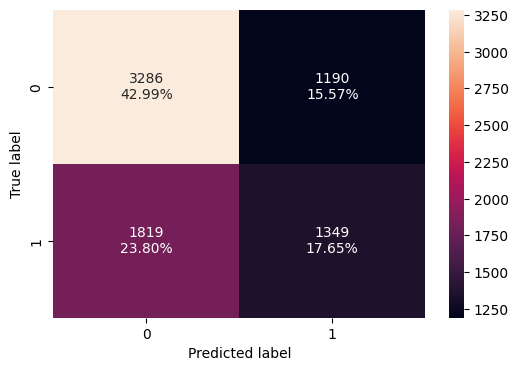

In [285]:
## Bagging LR Model(Base Model + Original Data)
bagging_lr=BaggingClassifier(estimator=LogisticRegression(solver='liblinear', random_state=1,class_weight='balanced'),random_state=1) 
bagging_lr.fit(x_train,y_train)

print("\n" "Training Performance:" "\n")
print(evaluation_metric(bagging_lr,x_train,y_train))
confusion_matrix_sklearn(bagging_lr,x_train,y_train)

print("\n" "Test Performance:" "\n")
print(evaluation_metric(bagging_lr,x_test,y_test))
confusion_matrix_sklearn(bagging_lr,x_test,y_test)

- Train and Test Recall/Precision results are very similar, which means that model can retained the learning very well.
- Evaluation Metric values are better than Decision Tree, Random Forest.

## 4. AdaBoost(Basic Model + Original Data)


Training Performance:

     Recall  Precision
0  0.374304   0.661989

Test Performance:

     Recall  Precision
0  0.380859   0.680028


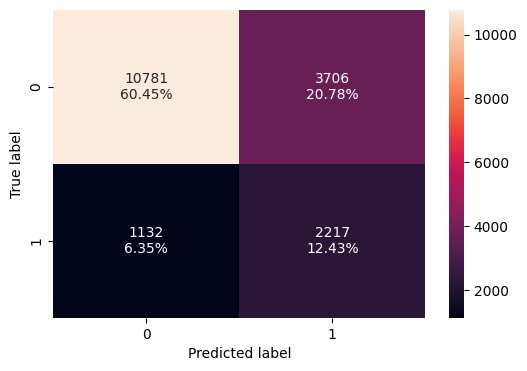

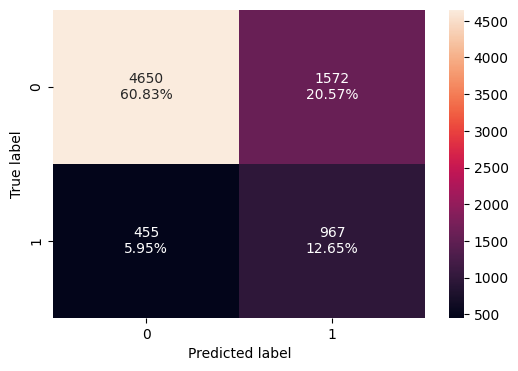

In [205]:
adb=AdaBoostClassifier(random_state=42)
adb.fit(x_train,y_train)
print("\n" "Training Performance:" "\n")
print(evaluation_metric(adb,x_train,y_train))
confusion_matrix_sklearn(adb,x_train,y_train)

print("\n" "Test Performance:" "\n")
print(evaluation_metric(adb,x_test,y_test))
confusion_matrix_sklearn(adb,x_test,y_test)

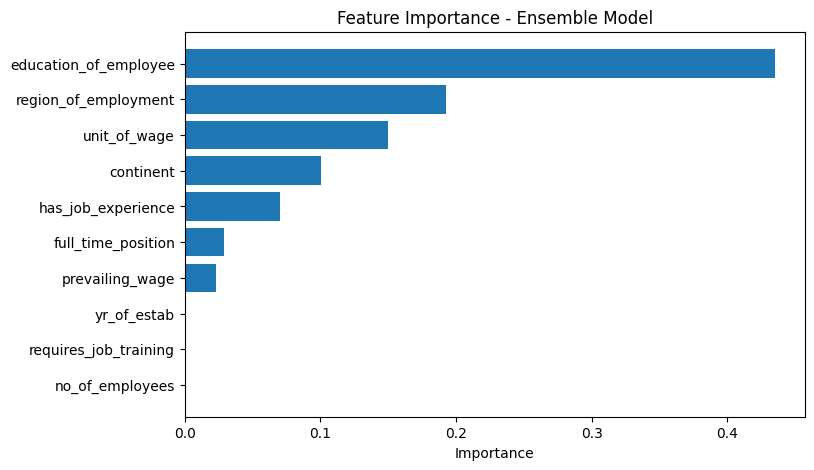

In [227]:
ensemble_feature_importance(adb, x_train)

- Education_of_employee is the most important feature followed by region_of_employement, unit_of_wage. This is very different from Random Forests and Decision Tree.
- Also the training and testing metrics are similar, suggesting the model retains the learning well.

## 5. Gradient Boosting(Basic Model + Original Data)


Training Performance:

     Recall  Precision
0  0.490123   0.672925

Test Performance:

     Recall  Precision
0  0.484049   0.666125


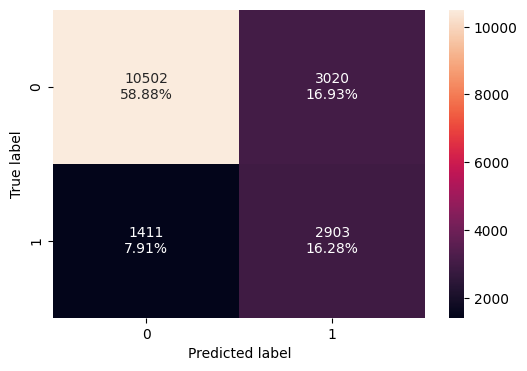

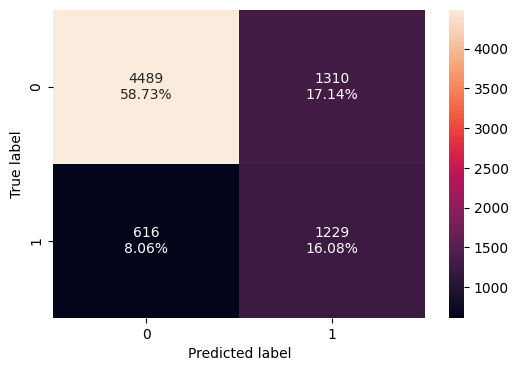

In [229]:
gb=GradientBoostingClassifier(random_state=42)
gb.fit(x_train,y_train)
print("\n" "Training Performance:" "\n")
print(evaluation_metric(gb,x_train,y_train))
confusion_matrix_sklearn(gb,x_train,y_train)

print("\n" "Test Performance:" "\n")
print(evaluation_metric(gb,x_test,y_test))
confusion_matrix_sklearn(gb,x_test,y_test)

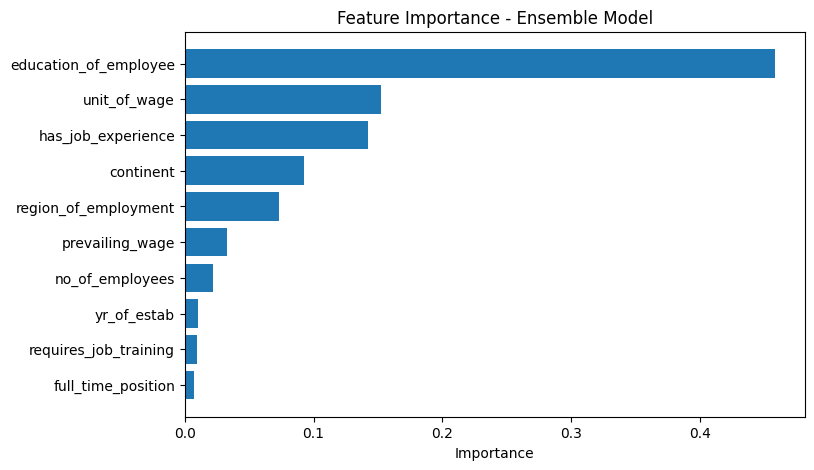

In [230]:
ensemble_feature_importance(gb, x_train)

- Education_of_employee is the most important feature followed by unit_of_wage, has_job_experience, continent, similar to Adaboost feature list.
- Gradient Boosting also have similar training and testing evalucation scores.

## 6. Xtreme Gradient Boosting(Basic Model + Original Data)


Training Performance:

     Recall  Precision
0  0.655749   0.827439

Test Performance:

     Recall  Precision
0  0.478141   0.625129


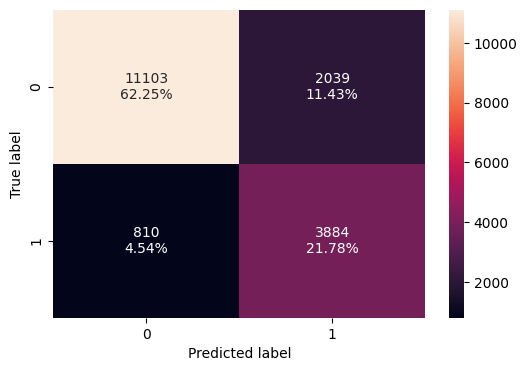

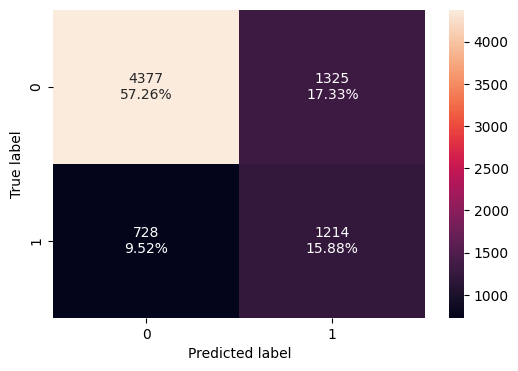

In [231]:
xgb=XGBClassifier(random_state=42)
xgb.fit(x_train,y_train)
print("\n" "Training Performance:" "\n")
print(evaluation_metric(xgb,x_train,y_train))
confusion_matrix_sklearn(xgb,x_train,y_train)

print("\n" "Test Performance:" "\n")
print(evaluation_metric(xgb,x_test,y_test))
confusion_matrix_sklearn(xgb,x_test,y_test)

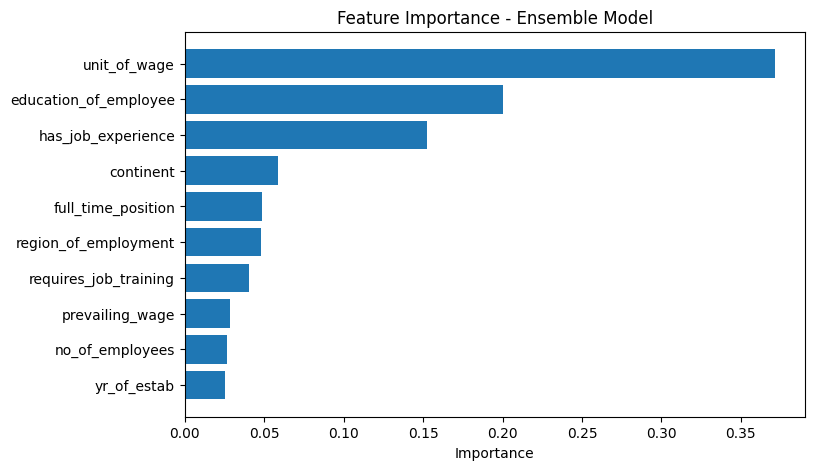

In [232]:
ensemble_feature_importance(xgb, x_train)

- Although XG boost is considered to be a better model than Gradient Boost but the result tell a different story.

## 7. CatBoost(Basic Model + Original Data)


Training Performance:

     Recall  Precision
0  0.565254   0.751684

Test Performance:

     Recall  Precision
0  0.487594   0.657113


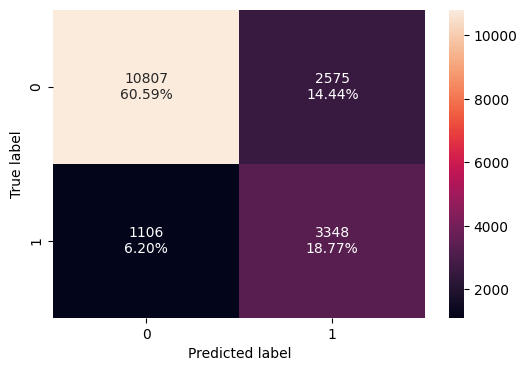

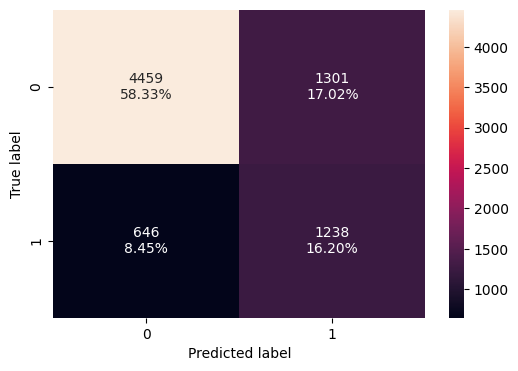

In [233]:
cb=CatBoostClassifier(random_state=42,verbose=False)
cb.fit(x_train,y_train)

print("\n" "Training Performance:" "\n")
print(evaluation_metric(cb,x_train,y_train))
confusion_matrix_sklearn(cb,x_train,y_train)

print("\n" "Test Performance:" "\n")
print(evaluation_metric(cb,x_test,y_test))
confusion_matrix_sklearn(cb,x_test,y_test)

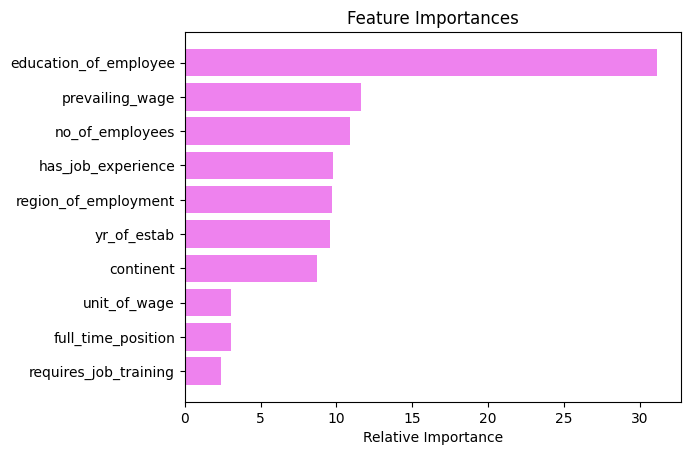

In [234]:
importance(cb,x_train,y_train)

## Observation on Basic Models + Original Data
- Top 3 important features are Education_of_employee,has_job_experience, unit_of_wage.
- All models have recall score of ~.45, with best being .53 by Bagging Logistic Regression.
- Random Forest, Decision tree overfit the train data and not the best models to be used without any pruning.
- All bagging and boosting models have a good retention power in train and test data.

## Oversampling the Data

## Training Models(Basic + Baaging + Boosting) + Oversampled Data

In [237]:
print("Before Oversampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
)  # Synthetic Minority Over Sampling Technique
x_train_over, y_train_over = sm.fit_resample(x_train, y_train)


print("After Oversampling, counts of label 'Yes': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of label 'No': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(x_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of label 'Yes': 5923
Before Oversampling, counts of label 'No': 11913 

After Oversampling, counts of label 'Yes': 11913
After Oversampling, counts of label 'No': 11913 

After Oversampling, the shape of train_X: (23826, 10)
After Oversampling, the shape of train_y: (23826,) 



In [297]:
model_over = []  # Empty list to store all the models

# Appending models into the list
model_over.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
model_over.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
model_over.append(("Bagging", BaggingClassifier(estimator=LogisticRegression(solver='liblinear', random_state=1),random_state=1)))
model_over.append(("Adaboost", AdaBoostClassifier(random_state=1)))
model_over.append(("GBM", GradientBoostingClassifier(random_state=1)))
model_over.append(("XGBoost", XGBClassifier( random_state=1,eval_metric='logloss',use_label_encoder=False  )))# avoids warning use_label_encoder=False
model_over.append(("catboost", CatBoostClassifier(random_state=42,verbose=False)))


print("\n" "Training Performance:" "\n")
for name, model in model_over:
    model.fit(x_train_over, y_train_over)
    scores = recall_score(y_train_over, model.predict(x_train_over))
    print("{}: {}".format(name, scores))

print("\n" "Test Performance:" "\n")

for name, model in model_over:
    model.fit(x_train_over, y_train_over)
    scores = recall_score(y_test, model.predict(x_test))
    print("{}: {}".format(name, scores))
    results.append({
        "Model": name,
        "Dataset": "Oversampled",
        "Precision": precision_score(y_test, model.predict(x_test)),
        "Recall": recall_score(y_test, model.predict(x_test))
        
    })


Training Performance:

dtree: 1.0
Random forest: 0.9999160580878033
Bagging: 0.6140350877192983
Adaboost: 0.7277763787459078
GBM: 0.7196340132628222
XGBoost: 0.8307731050113322
catboost: 0.7722655922101905

Test Performance:

dtree: 0.5462780622292241
Random forest: 0.5833005120126034
Bagging: 0.5529736116581331
Adaboost: 0.6053564395431272
GBM: 0.5927530523828279
XGBoost: 0.5840882237101221
catboost: 0.5880267821977156


## Undersampling Data

In [240]:
rus = RandomUnderSampler(random_state=1)
x_train_un, y_train_un = rus.fit_resample(x_train, y_train)

In [241]:
print("Before Under Sampling, counts of label 'Yes': {}".format(sum(y_train == 1)))
print("Before Under Sampling, counts of label 'No': {} \n".format(sum(y_train == 0)))

print("After Under Sampling, counts of label 'Yes': {}".format(sum(y_train_un == 1)))
print("After Under Sampling, counts of label 'No': {} \n".format(sum(y_train_un == 0)))

print("After Under Sampling, the shape of train_X: {}".format(x_train_un.shape))
print("After Under Sampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Under Sampling, counts of label 'Yes': 5923
Before Under Sampling, counts of label 'No': 11913 

After Under Sampling, counts of label 'Yes': 5923
After Under Sampling, counts of label 'No': 5923 

After Under Sampling, the shape of train_X: (11846, 10)
After Under Sampling, the shape of train_y: (11846,) 



## Training Models(Basic + Baaging + Boosting) + Undersampled Data

In [303]:
model_under = []  # Empty list to store all the models

# Appending models into the list
model_under.append(("dtree", DecisionTreeClassifier(random_state=1, class_weight='balanced')))
model_under.append(("Random forest", RandomForestClassifier(random_state=1, class_weight='balanced')))
model_under.append(("Bagging", BaggingClassifier(estimator=LogisticRegression(solver='liblinear', random_state=1),random_state=1)))
model_under.append(("Adaboost", AdaBoostClassifier(random_state=1)))
model_under.append(("GBM", GradientBoostingClassifier(random_state=1)))
model_under.append(("XGBoost", XGBClassifier( random_state=1,eval_metric='logloss',use_label_encoder=False  )))# avoids warning use_label_encoder=False
model_under.append(("catboost", CatBoostClassifier(random_state=42,verbose=False)))

print("\n" "Training Performance:" "\n")
for name, model in model_under:
    model.fit(x_train_un, y_train_un)
    scores = recall_score(y_train_un, model.predict(x_train_un))
    print("{}: {}".format(name, scores))

print("\n" "Test Performance:" "\n")

for name, model in model_under:
    model.fit(x_train_un, y_train_un)
    scores = recall_score(y_test, model.predict(x_test))
    print("{}: {}".format(name, scores))
    results.append({
        "Model": name,
        "Dataset": "Undersampled",
        "Precision": precision_score(y_test, model.predict(x_test)),
        "Recall": recall_score(y_test, model.predict(x_test))
        
    })


Training Performance:

dtree: 1.0
Random forest: 1.0
Bagging: 0.5612020935336822
Adaboost: 0.6518656086442681
GBM: 0.7023467837244639
XGBoost: 0.8521019753503293
catboost: 0.770893128482188

Test Performance:

dtree: 0.6104765655769988
Random forest: 0.6880661677825916
Bagging: 0.558487593540764
Adaboost: 0.6561638440330839
GBM: 0.697518708152816
XGBoost: 0.6955494289090193
catboost: 0.6990941315478535


# Hyper Tuning
- For best estimator among the hypertune parameters, using Randomized search grid is preferred for less computational power and time and optimal result.

## Choosing 3 best Models 
### **CatBoost, GradientBoost, XG Boost because:**

- Highest recall across all models → catches maximum potential customers

- Handles categorical/imbalanced data extremely well

- Already strong without tuning → high upside after tuning

- Best balance of Recall + Precision

## 1. CatBoost(Hypertune Model + Original Data)

In [250]:
cb_tune = CatBoostClassifier(random_state=42,verbose=False)


# Grid of parameters to choose from
param_grid = {
                "depth": [4, 6, 8],
                "learning_rate": [0.01, 0.05, 0.1],
                "iterations": [200, 400],
                "l2_leaf_reg": [1, 3, 5]
             }

# Run the grid search
grid_obj = RandomizedSearchCV(cb_tune, param_grid, scoring='recall',cv=5)
##grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
##cb_tune = grid_obj.best_estimator_

# Fit the best algorithm to the data.
cb_tune.fit(x_train, y_train)

print("\n" "Training Performance:" "\n")
print(evaluation_metric(cb_tune,x_train,y_train))
print("\n" "Test Performance:" "\n")
print(evaluation_metric(cb_tune,x_test,y_test))


Training Performance:

     Recall  Precision
0  0.565254   0.751684

Test Performance:

     Recall  Precision
0  0.487594   0.657113


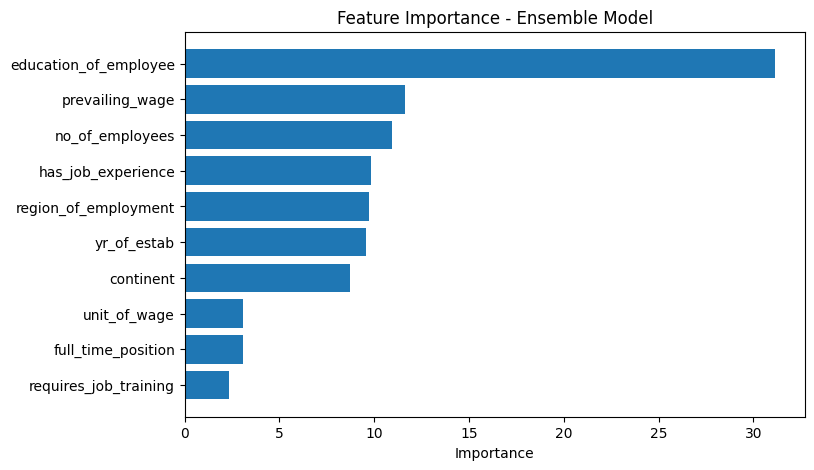

In [263]:
ensemble_feature_importance(cb_tune, x_train)

## 2. Xtreme GradientBoosting(Hypertune Model + Original Data)

In [249]:
xgb_tune=XGBClassifier(random_state=42)

# Grid of parameters to choose from
param_grid = {
                'n_estimators': [75,100,125,150],
              'subsample':[0.7, 0.8, 0.9, 1],
              'gamma':[0, 1, 3, 5],
              'colsample_bytree':[0.7, 0.8, 0.9, 1],
              'colsample_bylevel':[0.7, 0.8, 0.9, 1]
             }

# Run the grid search
grid_obj = RandomizedSearchCV(xgb_tune, param_grid, scoring='recall',cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
xgb_tune = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tune.fit(x_train, y_train)

print("\n" "Training Performance:" "\n")
print(evaluation_metric(xgb_tune,x_train,y_train))
print("\n" "Test Performance:" "\n")
print(evaluation_metric(xgb_tune,x_test,y_test))


Training Performance:

     Recall  Precision
0  0.512747   0.666886

Test Performance:

     Recall  Precision
0  0.505711   0.663566


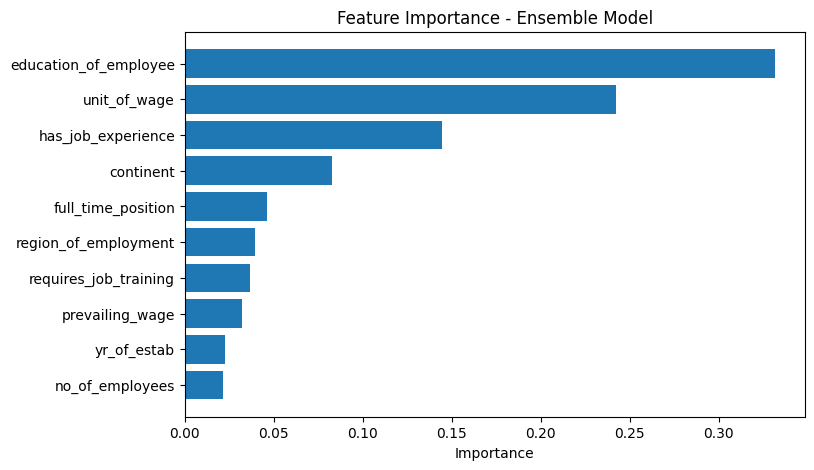

In [262]:
ensemble_feature_importance(xgb_tune, x_train)

## 3. Gradient Boosting(Hypertune Model + Original Data)

In [248]:
gb_tune = GradientBoostingClassifier(random_state=42)

# Grid of parameters to choose from
param_grid = {
                'n_estimators': np.arange(50,200,25),
              'subsample':[0.7,0.8,0.9,1],
              'max_features':[0.7,0.8,0.9,1],
              'max_depth':[3,5,7,10]
             }

# Run the grid search
grid_obj = RandomizedSearchCV(gb_tune, param_grid, scoring='recall',cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
gb_tune = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gb_tune.fit(x_train, y_train)

print("\n" "Training Performance:" "\n")
print(evaluation_metric(gb_tune,x_train,y_train))
print("\n" "Test Performance:" "\n")
print(evaluation_metric(gb_tune,x_test,y_test))


Training Performance:

     Recall  Precision
0  0.622657   0.807179

Test Performance:

     Recall  Precision
0  0.486412   0.652404


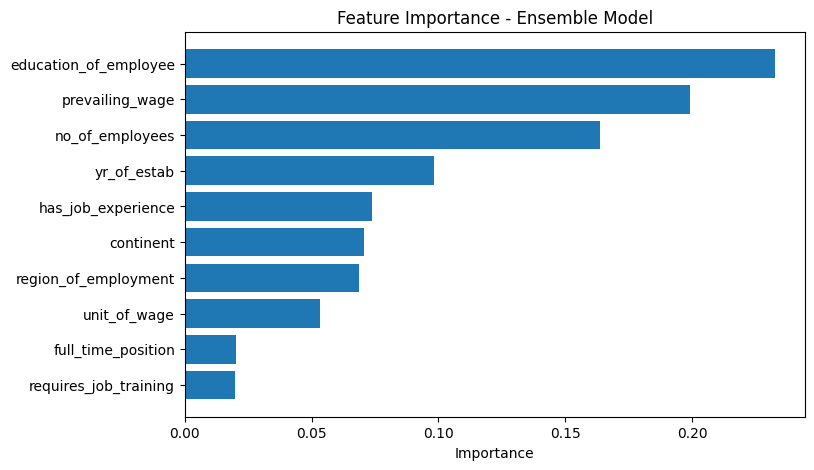

In [261]:
ensemble_feature_importance(gb_tune, x_train)

## (Optional) Random Forest(Hypertune Model + Original Data)

In [243]:
rf_tune = RandomForestClassifier(random_state=42)

# Grid of parameters to choose from
param_grid = {
                "n_estimators": [110,251,501],
                "min_samples_leaf": np.arange(1, 6,1),
                "max_features": [0.7,0.9,'log2','auto'],
                "max_samples": [0.7,0.9,None]
             }

# Run the grid search
grid_obj = RandomizedSearchCV(rf_tune, param_grid, scoring='recall',cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
rf_tune = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tune.fit(x_train, y_train)


print("\n" "Training Performance:" "\n")
print(evaluation_metric(rf_tune,x_train,y_train))
print("\n" "Test Performance:" "\n")
print(evaluation_metric(rf_tune,x_test,y_test))


Training Performance:

     Recall  Precision
0  0.830154   0.952353

Test Performance:

     Recall  Precision
0  0.484049   0.625445


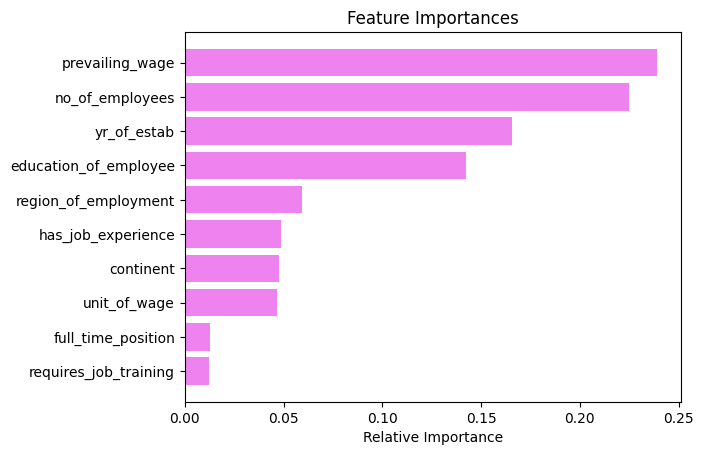

In [252]:
importance(rf_tune,x_train,y_train)

## (Optional) Decision Tree(Hypertune Model + Original Data)

In [235]:
dt_tune = DecisionTreeClassifier(random_state=42)

# Grid of parameters to choose from
param_grid = {
                'max_depth' : np.arange(2, 7, 1),
                'max_leaf_nodes' : [10, 20, 30, 50],
                'min_samples_split' : [10, 30, 50, 70]
             }

# Run the grid search
grid_obj = RandomizedSearchCV(dt_tune, param_grid, scoring='recall',cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
dt_tune = grid_obj.best_estimator_

# Fit the best algorithm to the data.
dt_tune.fit(x_train, y_train)

print("\n" "Training Performance:" "\n")
print(evaluation_metric(dt_tune,x_train,y_train))
print("\n" "Test Performance:" "\n")
print(evaluation_metric(dt_tune,x_test,y_test))


Training Performance:

     Recall  Precision
0  0.440149     0.6659

Test Performance:

     Recall  Precision
0  0.428121   0.658389


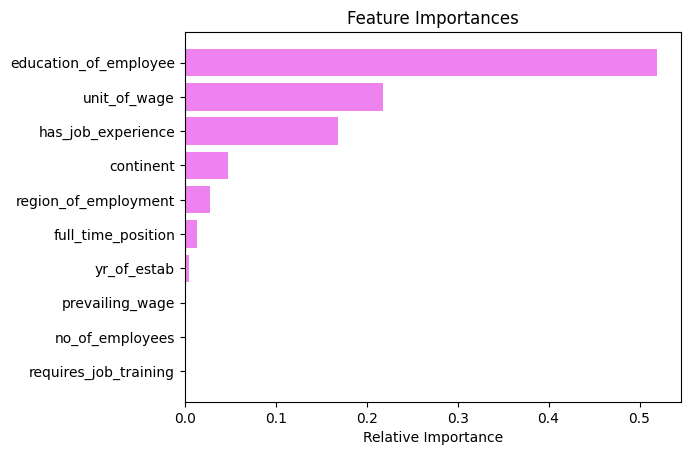

In [251]:
importance(dt_tune,x_train,y_train)

- Recall for hypertuned decision tree is less than raw unpruned tree but same is not true for precision.
- Retention has definitely increased from training to test data.
  

## (Optional) Bagging LR Model(Hypertune Model + Original Data)

In [287]:

# Base model
bagging_lr_tune = BaggingClassifier(
        estimator=LogisticRegression(
            solver='liblinear',
            random_state=1
        ),
        random_state=1
)

# Parameter distributions
param_dist = {

    # Bagging params
    'n_estimators': [10, 20, 50, 100],
    'max_samples': [0.6, 0.8, 1.0],
    'max_features': [0.6, 0.8, 1.0],
    'bootstrap': [True, False],

    # Logistic Regression params (IMPORTANT prefix)
    'estimator__C': np.logspace(-2, 2, 10),
    'estimator__penalty': ['l1', 'l2'],
    'estimator__class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
        estimator=bagging_lr_tune,
        param_distributions=param_dist,
        n_iter=25,
        scoring='recall',   # since we care about recall
        cv=5,
        n_jobs=-1,
        verbose=2,
        random_state=42
)

# Train search
random_search.fit(x_train, y_train)

# Best model
bagging_lr_tune = random_search.best_estimator_

# Evaluate
print("\n" "Training Performance:" "\n")
print(evaluation_metric(bagging_lr_tune,x_train,y_train))
print("\n" "Test Performance:" "\n")
print(evaluation_metric(bagging_lr_tune,x_test,y_test))


Fitting 5 folds for each of 25 candidates, totalling 125 fits

Training Performance:

    Recall  Precision
0  0.56002    0.39696

Test Performance:

     Recall  Precision
0  0.556912   0.395193


## (Optional) AdaBoosting (Hypertune Model + Original Data)

In [245]:

adb_tune = AdaBoostClassifier(random_state=42)

# Grid of parameters to choose from
param_grid = {
                'n_estimators': np.arange(10,100,10),
                'learning_rate': [1, 0.1, 0.5, 0.01]
             }

# Run the grid search
grid_obj = RandomizedSearchCV(adb_tune, param_grid, scoring='recall',cv=5)
grid_obj = grid_obj.fit(x_train, y_train)

# Set the clf to the best combination of parameters
adb_tune = grid_obj.best_estimator_

# Fit the best algorithm to the data.
adb_tune.fit(x_train, y_train)
print("\n" "Training Performance:" "\n")
print(evaluation_metric(adb_tune,x_train,y_train))
print("\n" "Test Performance:" "\n")
print(evaluation_metric(adb_tune,x_test,y_test))


Training Performance:

    Recall  Precision
0  0.32703   0.654392

Test Performance:

     Recall  Precision
0  0.334384   0.671146


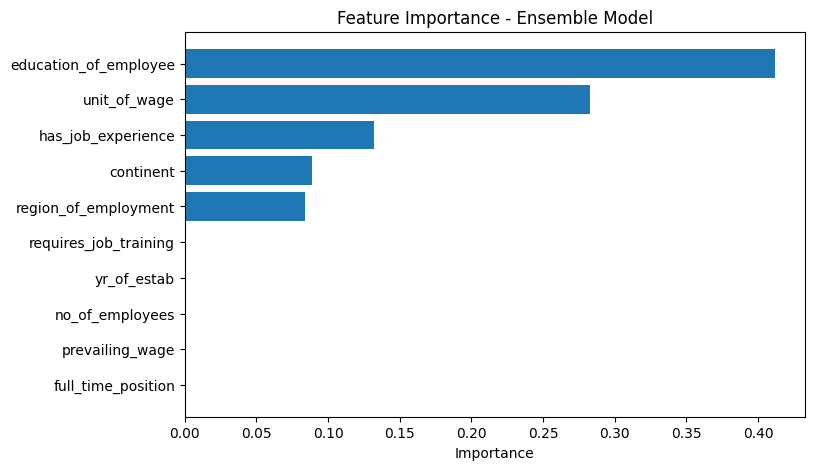

In [258]:
ensemble_feature_importance(adb_tune, x_train)

## Comparing Model Results

In [273]:
def evaluate_model(model, x_test, y_test, model_name, version):
    
    y_pred = model.predict(x_test)

    try:
        y_prob = model.predict_proba(x_test)[:,1]
        roc_auc = roc_auc_score(y_test, y_prob)
    except:
        roc_auc = None

    return {
        "Model": model_name,
        "Version": version,
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred)
    }

## Aggregating Recall and Precision across Model for Comparison

In [316]:
results = []

# Decision Tree
results.append(evaluate_model(dt, x_test, y_test, "Decision Tree", "Basic"))
results.append(evaluate_model(dt_tune, x_test, y_test, "Decision Tree", "Tuned"))
results.append(evaluate_model(model_over[0][1],  x_test, y_test, "Decision Tree", "OverSampled"))
results.append(evaluate_model(model_under[0][1], x_test, y_test, "Decision Tree", "UnderSampled"))

# Random Forest
results.append(evaluate_model(rf, x_test, y_test, "Random Forest", "Basic"))
results.append(evaluate_model(rf_tune, x_test, y_test, "Random Forest", "Tuned"))
results.append(evaluate_model(model_over[1][1],  x_test, y_test, "Random Forest", "OverSampled"))
results.append(evaluate_model(model_under[1][1], x_test, y_test, "Random Forest", "UnderSampled"))

# Bagging Logistic Regression
results.append(evaluate_model(bagging_lr_basic, x_test, y_test, "Bagging LR", "Basic"))
results.append(evaluate_model(bagging_lr, x_test, y_test, "Bagging LR", "Tuned"))
results.append(evaluate_model(model_over[2][1],  x_test, y_test, "Bagging LR", "OverSampled"))
results.append(evaluate_model(model_under[2][1], x_test, y_test, "Bagging LR", "UnderSampled"))

#AdaBoost
results.append(evaluate_model(adb, x_test, y_test, "AdaBoost", "Basic"))
results.append(evaluate_model(adb_tune, x_test, y_test, "AdaBoost", "Tuned"))
results.append(evaluate_model(model_over[3][1],  x_test, y_test, "AdaBoost", "OverSampled"))
results.append(evaluate_model(model_under[3][1], x_test, y_test, "AdaBoost", "UnderSampled"))

#Gradient Boosting
results.append(evaluate_model(gb, x_test, y_test, "Gradient Boost", "Basic"))
results.append(evaluate_model(gb_tune, x_test, y_test, "Gradient Boost", "Tuned"))
results.append(evaluate_model(model_over[4][1],  x_test, y_test, "Gradient Boost", "OverSampled"))
results.append(evaluate_model(model_under[4][1], x_test, y_test, "Gradient Boost", "UnderSampled"))

#XGBoost
results.append(evaluate_model(xgb, x_test, y_test, "XGBoost", "Basic"))
results.append(evaluate_model(xgb_tune, x_test, y_test, "XGBoost", "Tuned"))
results.append(evaluate_model(model_over[5][1],  x_test, y_test, "XGBoost", "OverSampled"))
results.append(evaluate_model(model_under[5][1], x_test, y_test, "XGBoost", "UnderSampled"))

#CatBoost
results.append(evaluate_model(cb, x_test, y_test, "CatBoost", "Basic"))
results.append(evaluate_model(cb_tune, x_test, y_test, "CatBoost", "Tuned"))
results.append(evaluate_model(model_over[6][1],  x_test, y_test, "CatBoost", "OverSampled"))
results.append(evaluate_model(model_under[6][1], x_test, y_test, "CatBoost", "UnderSampled"))

In [321]:
train_results = []

# Decision Tree
train_results.append(evaluate_model(dt, x_train, y_train, "Decision Tree", "Basic"))
train_results.append(evaluate_model(dt_tune, x_train, y_train, "Decision Tree", "Tuned"))
train_results.append(evaluate_model(model_over[0][1],  x_train, y_train, "Decision Tree", "OverSampled"))
train_results.append(evaluate_model(model_under[0][1], x_train, y_train, "Decision Tree", "UnderSampled"))

# Random Forest
train_results.append(evaluate_model(rf, x_train, y_train, "Random Forest", "Basic"))
train_results.append(evaluate_model(rf_tune, x_train, y_train, "Random Forest", "Tuned"))
train_results.append(evaluate_model(model_over[1][1],  x_train, y_train, "Random Forest", "OverSampled"))
train_results.append(evaluate_model(model_under[1][1], x_train, y_train, "Random Forest", "UnderSampled"))

# Bagging Logistic Regression
train_results.append(evaluate_model(bagging_lr_basic, x_train, y_train, "Bagging LR", "Basic"))
train_results.append(evaluate_model(bagging_lr, x_train, y_train, "Bagging LR", "Tuned"))
train_results.append(evaluate_model(model_over[2][1],  x_train, y_train, "Bagging LR", "OverSampled"))
train_results.append(evaluate_model(model_under[2][1], x_train, y_train, "Bagging LR", "UnderSampled"))

# AdaBoost
train_results.append(evaluate_model(adb, x_train, y_train, "AdaBoost", "Basic"))
train_results.append(evaluate_model(adb_tune, x_train, y_train, "AdaBoost", "Tuned"))
train_results.append(evaluate_model(model_over[3][1],  x_train, y_train, "AdaBoost", "OverSampled"))
train_results.append(evaluate_model(model_under[3][1], x_train, y_train, "AdaBoost", "UnderSampled"))

# Gradient Boost
train_results.append(evaluate_model(gb, x_train, y_train, "Gradient Boost", "Basic"))
train_results.append(evaluate_model(gb_tune, x_train, y_train, "Gradient Boost", "Tuned"))
train_results.append(evaluate_model(model_over[4][1],  x_train, y_train, "Gradient Boost", "OverSampled"))
train_results.append(evaluate_model(model_under[4][1], x_train, y_train, "Gradient Boost", "UnderSampled"))

# XGBoost
train_results.append(evaluate_model(xgb, x_train, y_train, "XGBoost", "Basic"))
train_results.append(evaluate_model(xgb_tune, x_train, y_train, "XGBoost", "Tuned"))
train_results.append(evaluate_model(model_over[5][1],  x_train, y_train, "XGBoost", "OverSampled"))
train_results.append(evaluate_model(model_under[5][1], x_train, y_train, "XGBoost", "UnderSampled"))

# CatBoost
train_results.append(evaluate_model(cb, x_train, y_train, "CatBoost", "Basic"))
train_results.append(evaluate_model(cb_tune, x_train, y_train, "CatBoost", "Tuned"))
train_results.append(evaluate_model(model_over[6][1],  x_train, y_train, "CatBoost", "OverSampled"))
train_results.append(evaluate_model(model_under[6][1], x_train, y_train, "CatBoost", "UnderSampled"))

# Convert to DataFrame
train_results_df = pd.DataFrame(train_results)


## Sorting Test Data performance by Recall 

In [320]:
train_df = train_results_df.rename(columns={
    "Recall": "Train_Recall",
    "Precision": "Train_Precision"
})

test_df = results_df.rename(columns={
    "Recall": "Test_Recall",
    "Precision": "Test_Precision"
})

combined_df = pd.merge(
    train_df,
    test_df,
    on=["Model", "Version"],
    how="inner"
)

combined_df["Recall_Diff"] = combined_df["Train_Recall"] - combined_df["Test_Recall"]
combined_df["Precision_Diff"] = combined_df["Train_Precision"] - combined_df["Test_Precision"]

final_df = combined_df.sort_values(
    by=["Test_Recall", "Recall_Diff"],
    ascending=[False, False]
)

final_df = final_df[[
    "Model", "Version",
    "Train_Recall", "Test_Recall", "Recall_Diff",
    "Train_Precision", "Test_Precision", "Precision_Diff"
]]

final_df

,Model,Version,Train_Recall,Test_Recall,Recall_Diff,Train_Precision,Test_Precision,Precision_Diff
27,CatBoost,UnderSampled,0.770893,0.699094,0.071799,0.605651,0.560114,0.045537
19,Gradient Boost,UnderSampled,0.702347,0.697519,0.004828,0.558990,0.557971,0.001019
23,XGBoost,UnderSampled,0.852102,0.695549,0.156553,0.651058,0.535152,0.115906
7,Random Forest,UnderSampled,1.000000,0.688066,0.311934,0.761213,0.531488,0.229726
15,AdaBoost,UnderSampled,0.651866,0.656164,-0.004298,0.540000,0.547846,-0.007846
3,Decision Tree,UnderSampled,1.000000,0.610477,0.389523,0.724881,0.445019,0.279862
14,AdaBoost,OverSampled,0.605436,0.605356,0.000080,0.528519,0.532202,-0.003683
18,Gradient Boost,OverSampled,0.596826,0.592753,0.004073,0.561468,0.561987,-0.000519
26,CatBoost,OverSampled,0.663346,0.588027,0.075319,0.640842,0.569413,0.071429
22,XGBoost,OverSampled,0.745062,0.584088,0.160973,0.710514,0.556682,0.153832


## Observation

### Highest Test Recall (better at catching positives):

- CatBoost (UnderSample) : 0.699

- Gradient Boost (UnderSample) : 0.698

- XGBoost (UnderSample) : 0.696

- Random Forest (UnderSample) : 0.688

- **UnderSampling + boosting models are clearly performing best in identifying true positives.**

### Stability (Overfitting Check – Recall_Diff)

- Large Recall_Diff = Overfitting risk.

- Stable Models (low recall diff):

- Gradient Boost (UnderSample) → 0.0048

- AdaBoost (OverSample) → ~0

- Bagging LR → very stable (~0.002)

### Highly Overfitted Models:

- Decision Tree (Basic) → 0.508

- Random Forest (OverSample) → 0.416

- Decision Tree (OverSample) → 0.453

- **Single trees and heavily oversampled forests are memorizing training data.**

### For a real-world ML deployment:
-  Use Gradient Boost (UnderSample) as primary model
-  Keep CatBoost (UnderSample) as challenger model

## Recommendation

### EasyVisa should implement a risk-tiered review system:

### **1.Fast Track**

- Advanced degree

- High wage

- Full-time role

- Experienced candidate

- Established employer

### **2.Standard Review**

- Mid-level wages

- Bachelor’s degree

- Moderate experience

### **3.Detailed Scrutiny**

- Low wage offers

- Part-time roles

- Small/new employer

- No prior experience

### Visa approvals are strongly driven by:

- Skill level (education + experience)

- Economic value (wage level)

- Employer credibility

- Job stability (full-time roles)

The business should focus on prioritizing high-skill, high-wage, stable employment applications to improve approval efficiency and reduce review burden.